# Population Density Dataset — Analysis

Columns are grouped in blocks:

| Block | Meaning |
| ----- | ------- |
| Total / Homme / Femme | Total population | 
| Total.1 / Homme.1 / Femme.1 | Swiss population |
| Total.2 / Homme.2 / Femme.2 | Foreign population |
| Total.3 / Homme.3 / Femme.3 | Non-permanent population |



In [5]:
import pandas as pd

df = pd.read_excel("../data/population.xlsx",sheet_name=0, header=3)

df = df.rename(columns={
    "Unnamed: 0": "region",
    "Total": "total_pop",
    "Homme": "male",
    "Femme": "female",
    "Total.1": "swiss_pop",
    "Total.2": "foreign_pop",
    "Total.3": "non_permanent_pop"
})

df = df.dropna(subset=["region"])
df.head()

,region,total_pop,male,female,swiss_pop,Homme.1,Femme.1,foreign_pop,Homme.2,Femme.2,non_permanent_pop,Homme.3,Femme.3
0,Suisse,9067144.0,4509263.0,4557881.0,6573203.0,3198037.0,3375166.0,2493941.0,1311226.0,1182715.0,84151.0,49840.0,34311.0
1,Région lémanique,1762775.0,866090.0,896685.0,1150317.0,549260.0,601057.0,612458.0,316830.0,295628.0,24380.0,13649.0,10731.0
2,Vaud,857445.0,422116.0,435329.0,565375.0,269528.0,295847.0,292070.0,152588.0,139482.0,9925.0,5357.0,4568.0
3,Valais,372573.0,186207.0,186366.0,274902.0,133754.0,141148.0,97671.0,52453.0,45218.0,10030.0,6103.0,3927.0
4,Genève,532757.0,257767.0,274990.0,310040.0,145978.0,164062.0,222717.0,111789.0,110928.0,4425.0,2189.0,2236.0


## Basic statistics

### Total population

In [6]:
total_population = df.loc[df["region"] == "Suisse", "total_pop"].values[0]
print("Total population Switzerland:", total_population)

Total population Switzerland: 9067144.0


### Population by canton

In [7]:
cantons = df[~df["region"].str.contains("Région|Suisse")]

cantons[["region", "total_pop"]].sort_values("total_pop", ascending=False).head(10)

,region,total_pop
5,Espace Mittelland,1964984.0
15,Zurich,1622494.0
6,Berne,1072948.0
2,Vaud,857445.0
14,Argovie,737276.0
21,Saint-Gall,541026.0
4,Genève,532757.0
25,Lucerne,438692.0
3,Valais,372573.0
31,Tessin,358696.0


### Population distribution

In [8]:
cantons["total_pop"].describe()

count    2.700000e+01
mean     4.085973e+05
std      4.813598e+05
min      1.670400e+04
25%      8.198650e+04
50%      2.901570e+05
75%      4.857245e+05
max      1.964984e+06
Name: total_pop, dtype: float64

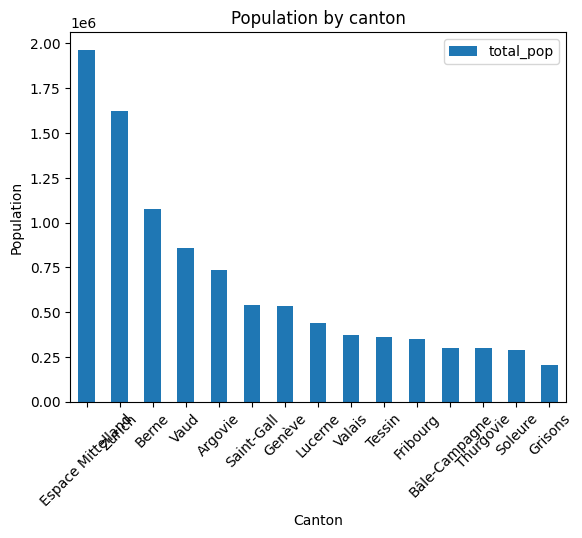

In [11]:
import matplotlib.pyplot as plt

cantons_sorted = cantons.sort_values("total_pop", ascending=False)

cantons_sorted.head(15).plot(
    x="region",
    y="total_pop",
    kind="bar"
)

plt.title("Population by canton")
plt.ylabel("Population")
plt.xlabel("Canton")
plt.xticks(rotation=45)
plt.show()